In [ ]:
# # 03_cluster0_metformin_gradient.ipynb — Step 1 (continued): Inspect medications.csv structure

# import os
# import pandas as pd

# print("File size (MB):", round(os.path.getsize("../data/csv/medications.csv") / 1e6, 1))

# meds_sample = pd.read_csv("../data/csv/medications.csv", nrows=5)
# print("\nColumns:", meds_sample.columns.tolist())
# meds_sample

File size (MB): 307.1

Columns: ['START', 'STOP', 'PATIENT', 'PAYER', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'BASE_COST', 'PAYER_COVERAGE', 'DISPENSES', 'TOTALCOST', 'REASONCODE', 'REASONDESCRIPTION']


,START,STOP,PATIENT,PAYER,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,PAYER_COVERAGE,DISPENSES,TOTALCOST,REASONCODE,REASONDESCRIPTION
0,2023-12-10T04:18:57Z,2023-12-24T04:18:57Z,7c9e3c55-f225-5b68-ee2f-dab71e12772c,df166300-5a78-3502-a46a-832842197811,7c9e3c55-f225-5b68-62a3-9dd0e0c44545,198405,Ibuprofen 100 MG Oral Tablet,50.64,0.64,1,50.64,NaN,NaN
1,2016-06-02T13:43:58Z,2016-06-29T13:43:58Z,720fe4ff-be67-e0d7-ff15-d5fee26722a6,b046940f-1664-3047-bca7-dfa76be352a4,720fe4ff-be67-e0d7-764b-43f739d50a90,849574,Naproxen sodium 220 MG Oral Tablet,91.72,0.00,1,91.72,NaN,NaN
2,2016-08-31T14:57:49Z,2016-08-31T14:57:49Z,720fe4ff-be67-e0d7-ff15-d5fee26722a6,b046940f-1664-3047-bca7-dfa76be352a4,720fe4ff-be67-e0d7-0294-bd4dccd62007,1535362,sodium fluoride 0.0272 MG/MG Oral Gel,129.94,90.96,1,129.94,66383009.0,Gingivitis (disorder)
3,2016-03-24T14:20:27Z,2017-03-22T23:10:05Z,ab0556f8-1ae2-4d4c-e9c8-cce4446ea2f4,df166300-5a78-3502-a46a-832842197811,ab0556f8-1ae2-4d4c-4a71-a73c0040bca0,807283,levonorgestrel 0.000833 MG/HR Intrauterine Sys...,12.31,0.00,12,147.72,NaN,NaN
4,2019-03-19T13:56:45Z,2019-04-10T13:56:45Z,720fe4ff-be67-e0d7-ff15-d5fee26722a6,b046940f-1664-3047-bca7-dfa76be352a4,720fe4ff-be67-e0d7-7d12-ebf5c5d50a15,310965,Ibuprofen 200 MG Oral Tablet,93.15,0.00,1,93.15,NaN,NaN


In [ ]:
# Standard library
import sys
from pathlib import Path

# Data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap


# Project-local setup
sys.path.append("../src")
from plot_style import set_project_style, COLOR_DARK, COLOR_ACCENT, COLOR_BG, COLOR_BLUE, COLOR_GRAY

set_project_style()
data_dir = Path("../data/processed")

In [3]:
# 05_treatment_adherence.ipynb — Setup: load clustered patient table

# Load the full clustered cohort (all 1763 patients, all three clusters)
df = pd.read_parquet("../data/processed/patient_features_clustered.parquet")
df = df.reset_index()  # PATIENT becomes a regular column

# Full cohort IDs for medication extraction
cohort_ids = set(df["PATIENT"].values)

print("Cohort size:", len(cohort_ids))
print("Cluster distribution:\n", df["cluster_label"].value_counts())

Cohort size: 1763
Cluster distribution:
 cluster_label
Mild, lower treatment intensity      1303
Multimorbid, high care complexity     366
Dyslipidemic / metabolic               94
Name: count, dtype: int64


In [4]:
# 05_treatment_adherence.ipynb — Step 1: Chunked extraction of antidiabetic medication
# durations from medications.csv

# Drug class CODE mapping (exact codes from Phase 2 notebook 01 output)
code_to_class = {
    860975: "metformin",
    106892: "insulin",
    311034: "insulin",
    865098: "insulin",      # Humalog -- 4 patients, included for completeness
    897122: "other_antidiabetic",
    1373463: "other_antidiabetic"
}
antidiabetic_codes = set(code_to_class.keys())

# Chunked read -- same pattern as Phase 2 observations.csv extraction
chunk_size = 500_000
chunks = []

for chunk in pd.read_csv(
    "../data/csv/medications.csv",
    usecols=["PATIENT", "CODE", "START", "STOP"],
    chunksize=chunk_size,
    dtype={"CODE": "Int64"}  # nullable integer to handle any NaN before filtering
):
    mask = (
        chunk["PATIENT"].isin(cohort_ids) &
        chunk["CODE"].isin(antidiabetic_codes)
    )
    if mask.any():
        chunks.append(chunk[mask])

meds_raw = pd.concat(chunks, ignore_index=True)
meds_raw["CODE"] = meds_raw["CODE"].astype(int)  # back to standard int after concat

print(f"Rows extracted: {len(meds_raw)}")
print(f"Patients covered: {meds_raw['PATIENT'].nunique()}")
meds_raw.head()

Rows extracted: 85605
Patients covered: 1247


,START,STOP,PATIENT,CODE
0,2024-02-28T07:21:46Z,2024-04-03T07:21:46Z,9d45248b-a111-43c2-de54-41172572a655,106892
1,2024-04-03T07:21:46Z,2024-05-22T07:21:46Z,9d45248b-a111-43c2-de54-41172572a655,106892
2,2024-05-22T07:21:46Z,2024-06-19T07:21:46Z,9d45248b-a111-43c2-de54-41172572a655,106892
3,2024-06-19T07:21:46Z,2024-07-31T07:21:46Z,9d45248b-a111-43c2-de54-41172572a655,106892
4,2024-07-31T07:21:46Z,2024-08-07T07:21:46Z,9d45248b-a111-43c2-de54-41172572a655,106892


In [5]:
# 05_treatment_adherence.ipynb — Step 2: Calculate per-patient total days on therapy

# Parse dates (ISO format with timezone)
meds_raw["START"] = pd.to_datetime(meds_raw["START"], utc=True)
meds_raw["STOP"]  = pd.to_datetime(meds_raw["STOP"],  utc=True)

# Reference date for still-active prescriptions (STOP = NaN):
# latest START in the extracted dataset as proxy for Synthea simulation end.
# Conservative: does not inflate duration of ongoing prescriptions.
ref_date = meds_raw["START"].max()
print("Reference date (simulation end proxy):", ref_date.date())

# Fill missing STOP, compute duration in days
meds_raw["STOP_filled"] = meds_raw["STOP"].fillna(ref_date)
meds_raw["duration_days"] = (
    (meds_raw["STOP_filled"] - meds_raw["START"])
    .dt.total_seconds() / 86400
).clip(lower=0)

# Map CODE -> drug class
meds_raw["drug_class"] = meds_raw["CODE"].map(code_to_class)

# Sum durations per patient per drug class, then total across all classes
duration_by_class = (
    meds_raw
    .groupby(["PATIENT", "drug_class"])["duration_days"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

duration_by_class["treatment_days_total"] = (
    duration_by_class[
        [c for c in ["metformin", "insulin", "other_antidiabetic"]
         if c in duration_by_class.columns]
    ].sum(axis=1)
)

print("\nShape:", duration_by_class.shape)
print("\ntreatment_days_total distribution:")
print(duration_by_class["treatment_days_total"].describe().round(1))
duration_by_class.head()

Reference date (simulation end proxy): 2026-06-15

Shape: (1247, 5)

treatment_days_total distribution:
count     1247.0
mean      5330.8
std       5668.3
min          0.0
25%       2509.5
50%       3763.2
75%       6277.1
max      46383.8
Name: treatment_days_total, dtype: float64


drug_class,PATIENT,insulin,metformin,other_antidiabetic,treatment_days_total
0,0003c6da-971f-a2b1-8693-4c1a27f98985,3706.606470,0.000000,0.000000,3706.606470
1,0005fc0b-a254-8215-d848-1a20685b750f,0.000000,3657.248356,0.000000,3657.248356
2,0012304f-0715-b5e9-efa2-ee32e57cfb57,0.000000,3466.020937,0.000000,3466.020937
3,00681a7d-5dad-ecfe-af77-b65f8da3fa15,0.000000,3705.992569,0.000000,3705.992569
4,007624da-0aa5-4f25-4dc5-ae157d27cd46,246.295556,246.295556,246.295556,738.886667


In [6]:
# 05_treatment_adherence.ipynb — Step 3: Merge score with clustered cohort

# Left join: all 1763 cohort patients kept; those not in duration_by_class
# (no antidiabetic medication recorded) receive 0 for all drug class columns
df_scores = df.merge(
    duration_by_class[["PATIENT", "metformin", "insulin",
                        "other_antidiabetic", "treatment_days_total"]],
    on="PATIENT",
    how="left"
).fillna(0)

# Sanity check: cohort size preserved and zero-medication patients accounted for
print("Total patients:", len(df_scores))
print("Patients with treatment_days_total == 0:",
      (df_scores["treatment_days_total"] == 0).sum())
print("\nMean treatment_days_total by cluster:")
print(df_scores.groupby("cluster_label")["treatment_days_total"].mean().round(1))

Total patients: 1763
Patients with treatment_days_total == 0: 569

Mean treatment_days_total by cluster:
cluster_label
Dyslipidemic / metabolic             5032.1
Mild, lower treatment intensity      2401.3
Multimorbid, high care complexity    8321.3
Name: treatment_days_total, dtype: float64


**Treatment management modality: pharmacological vs. non-pharmacological**

The merged dataset reveals that 569 out of 1763 cohort patients (32.3%) have
`treatment_days_total = 0`, no antidiabetic medication recorded in `medications.csv`
for any of the six drug codes identified in Phase 2.

In a real-world T2D cohort, this subgroup most plausibly represents patients managed
through **non-pharmacological interventions** (diet, lifestyle modification, weight
management), a recognized and clinically valid first-line management strategy,
particularly in newly diagnosed patients with mild hyperglycemia or in those achieving
glycemic targets through behavioral change alone.

Including these patients in a treatment *intensity* or *adherence* analysis would be
conceptually incorrect: a score of zero days does not mean "low adherence", it means
"a different treatment modality altogether." Mixing the two groups would compress the
entire pharmacological gradient into the upper portion of the distribution and distort
all subsequent comparisons.

**Decision**: patients with `treatment_days_total = 0` are excluded from all treatment
intensity analyses in this notebook. They are treated as a distinct subgroup and
characterized separately (see plot below). The analytical dataset for intensity scoring
is restricted to the 1194 patients with at least one recorded antidiabetic prescription
(`treatment_days_total > 0`).

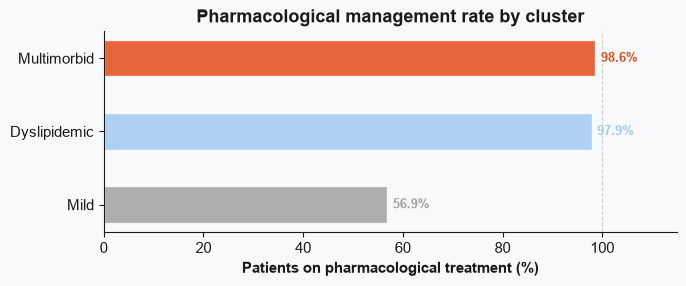


Raw counts:
  Mild, lower treatment intensity: 741/1303 (56.9%)
  Dyslipidemic / metabolic: 92/94 (97.9%)
  Multimorbid, high care complexity: 361/366 (98.6%)


In [28]:
# 05_treatment_adherence.ipynb — Step 3b (revised): barplot pharmacological rate

# Cluster order: Mild -> Dyslipidemic -> Multimorbid (ascending expected intensity)
cluster_order = [
    "Mild, lower treatment intensity",
    "Dyslipidemic / metabolic",
    "Multimorbid, high care complexity"
]

fig, ax = plt.subplots(figsize=(7, 3))

for i, label in enumerate(cluster_order):
    pct = pharma_pct.loc[
        pharma_pct["cluster_label"] == label, "pct_pharma"
    ].values[0]
    ax.barh(i, pct, color=cluster_colors[label], alpha=0.85, height=0.5)
    ax.annotate(
        f"{pct:.1f}%", xy=(pct, i), xytext=(4, 0),
        textcoords="offset points", fontsize=9,
        color=cluster_colors[label], va="center", fontweight="bold"
    )

ax.set_yticks(range(len(cluster_order)))
ax.set_yticklabels(["Mild", "Dyslipidemic", "Multimorbid"])
ax.set_xlim(0, 115)
ax.set_xlabel("Patients on pharmacological treatment (%)")
ax.set_title("Pharmacological management rate by cluster")
ax.axvline(100, color="#b0aea5", linewidth=0.8, linestyle="--", alpha=0.5)

# Remove top and right spines for cleaner look
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# Print raw counts for markdown
print("\nRaw counts:")
for label in cluster_order:
    sub = df_scores[df_scores["cluster_label"] == label]
    n_pharma = sub["pharmacological"].sum()
    n_total = len(sub)
    print(f"  {label}: {n_pharma}/{n_total} ({100*n_pharma/n_total:.1f}%)")

**Pharmacological management rate by cluster**: the three clusters differ sharply in
the proportion of patients receiving pharmacological treatment.

- **Multimorbid** (361/366, 98.6%) and **Dyslipidemic** (92/94, 97.9%): near-universal
  pharmacological management, consistent with their clinical profiles. Multimorbid
  patients carry the highest disease burden (CCI 4.34, Phase 3) and are almost
  exclusively on insulin; Dyslipidemic patients present a pronounced metabolic
  dysregulation that systematically requires pharmacological intervention.
- **Mild** (741/1303, 56.9%): only about half the cluster is on pharmacological
  treatment. The remaining 562 patients (43.1%) are managed through non-pharmacological
  means, diet, lifestyle modification, or watchful waiting, a clinically expected
  finding for a cluster defined by low disease burden and glycemic values closer to
  target (mean HbA1c 6.09, Phase 3).

This distribution reinforces the clinical validity of the Phase 3 cluster labels and
motivates the exclusion of zero-treatment patients from the intensity analysis below:
their `treatment_days_total = 0` reflects a different management modality, not low
adherence to pharmacological therapy.

In [21]:
# 05_treatment_adherence.ipynb — Step 3c: restrict analytical dataset to
# pharmacologically managed patients for all subsequent intensity analyses

df_pharma = df_scores[df_scores["treatment_days_total"] > 0].copy()

print(f"Analytical dataset: {len(df_pharma)} patients "
      f"({len(df_pharma)/len(df_scores)*100:.1f}% of full cohort)")
print("\nBy cluster:")
print(df_pharma["cluster_label"].value_counts())

Analytical dataset: 1194 patients (67.7% of full cohort)

By cluster:
cluster_label
Mild, lower treatment intensity      741
Multimorbid, high care complexity    361
Dyslipidemic / metabolic              92
Name: count, dtype: int64


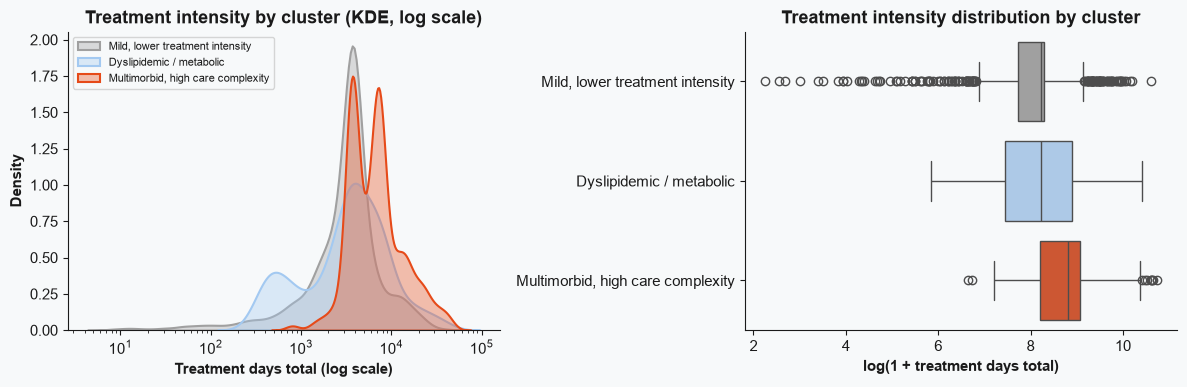

In [29]:
# 05_treatment_adherence.ipynb — Step 4 (revised): KDE instead of histogram for left panel

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: KDE per cluster, log-scaled x-axis
# bw_adjust=0.8 slightly tightens the bandwidth vs default (1.0) -- the log-scale
# spread is large enough that the default can over-smooth meaningful peaks
# fill=True adds a light shaded area under each curve for easier visual separation
for label in cluster_order:
    subset = df_pharma.loc[
        df_pharma["cluster_label"] == label, "treatment_days_total"
    ]
    # exclude zeros (untreated patients) from KDE: log(0) is undefined and they
    # would create a separate spike at the left edge that distorts the shape
    subset_nonzero = subset[subset > 0]
    sns.kdeplot(
        subset_nonzero,
        ax=axes[0],
        label=label,
        color=cluster_colors[label],
        fill=True,
        alpha=0.35,
        linewidth=1.5,
        bw_adjust=0.8,
        log_scale=True
    )

axes[0].set_xlabel("Treatment days total (log scale)")
axes[0].set_ylabel("Density")
axes[0].set_title("Treatment intensity by cluster (KDE, log scale)")
axes[0].legend(fontsize=8)

# Right: unchanged
sns.boxplot(
    data=df_pharma,
    x="treatment_days_log",
    y="cluster_label",
    hue="cluster_label",
    order=cluster_order,
    hue_order=cluster_order,
    palette=cluster_colors,
    legend=False,
    ax=axes[1]
)
axes[1].set_xlabel("log(1 + treatment days total)")
axes[1].set_ylabel("")
axes[1].set_title("Treatment intensity distribution by cluster")

plt.tight_layout()
plt.show()

In [25]:
# 05_treatment_adherence.ipynb — Step 5: Statistical comparison across clusters

from scipy.stats import kruskal, mannwhitneyu

# Kruskal-Wallis: non-parametric omnibus test (appropriate given the heavily
# right-skewed distribution and presence of zeros -- normality not assumed)
groups = [
    df_pharma.loc[df_pharma["cluster_label"] == label, "treatment_days_total"].values
    for label in cluster_order
]
stat, p_kruskal = kruskal(*groups)
print(f"Kruskal-Wallis H={stat:.1f}, p={p_kruskal:.2e}")

# Pairwise Mann-Whitney U tests (post-hoc, if Kruskal-Wallis is significant)
# No correction applied here (3 pairs, exploratory context)
pairs = [
    ("Mild, lower treatment intensity",   "Multimorbid, high care complexity"),
    ("Mild, lower treatment intensity",   "Dyslipidemic / metabolic"),
    ("Dyslipidemic / metabolic",          "Multimorbid, high care complexity")
]

print("\nPairwise Mann-Whitney U (two-sided):")
for a, b in pairs:
    x = df_pharma.loc[df_pharma["cluster_label"] == a, "treatment_days_total"]
    y = df_pharma.loc[df_pharma["cluster_label"] == b, "treatment_days_total"]
    u, p = mannwhitneyu(x, y, alternative="two-sided")
    # Effect size r = Z / sqrt(N)
    import scipy.stats as stats
    z = stats.norm.ppf(p / 2)
    r = abs(z) / np.sqrt(len(x) + len(y))
    print(f"  {a.split(',')[0]} vs {b.split(',')[0]}: U={u:.0f}, p={p:.2e}, r={r:.3f}")

Kruskal-Wallis H=170.7, p=8.77e-38

Pairwise Mann-Whitney U (two-sided):
  Mild vs Multimorbid: U=68643, p=2.21e-39, r=0.396
  Mild vs Dyslipidemic / metabolic: U=32579, p=4.89e-01, r=0.024
  Dyslipidemic / metabolic vs Multimorbid: U=10450, p=3.99e-08, r=0.258


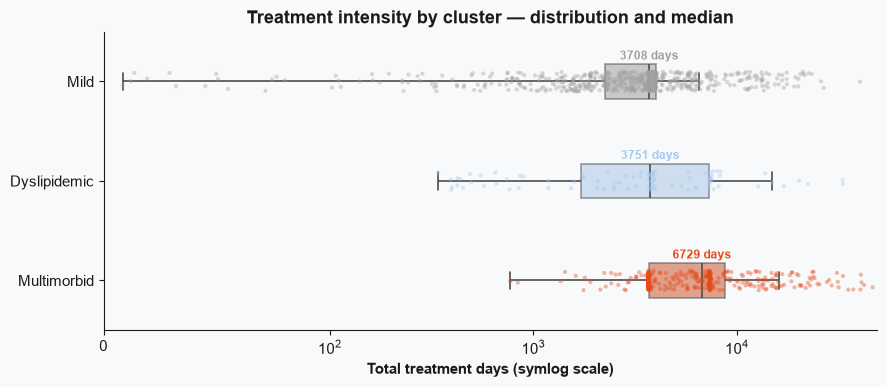

In [31]:
# 05_treatment_adherence.ipynb — Step 6 (revised): boxplot + jitter strip

fig, ax = plt.subplots(figsize=(9, 4))

# Strip (jittered individual points) -- plotted first so boxplot sits on top
sns.stripplot(
    data=df_pharma,
    x="treatment_days_total",
    y="cluster_label",
    order=cluster_order,
    hue="cluster_label",
    hue_order=cluster_order,
    palette=cluster_colors,
    size=3,
    alpha=0.40,
    jitter=True,
    legend=False,
    ax=ax
)

# Boxplot overlay -- fliersize=0 hides default outlier dots (already shown by strip)
sns.boxplot(
    data=df_pharma,
    x="treatment_days_total",
    y="cluster_label",
    order=cluster_order,
    hue="cluster_label",
    hue_order=cluster_order,
    palette=cluster_colors,
    width=0.35,
    linewidth=1.2,
    fliersize=0,
    boxprops=dict(alpha=0.55),
    legend=False,
    ax=ax
)

# Median annotations
for i, label in enumerate(cluster_order):
    median_val = df_pharma.loc[
        df_pharma["cluster_label"] == label, "treatment_days_total"
    ].median()
    ax.annotate(
        f"{median_val:.0f} days",
        xy=(median_val, i), xytext=(0, 14),
        textcoords="offset points",
        fontsize=8.5, color=cluster_colors[label],
        ha="center", va="bottom", fontweight="bold"
    )

ax.set_xscale("symlog", linthresh=100)
ax.set_xlim(left=0)           # axis starts at 0, no axvline needed
ax.set_xlabel("Total treatment days (symlog scale)")
ax.set_ylabel("")
ax.set_yticks(range(len(cluster_order)))
ax.set_yticklabels(["Mild", "Dyslipidemic", "Multimorbid"])
ax.set_title("Treatment intensity by cluster — distribution and median")
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

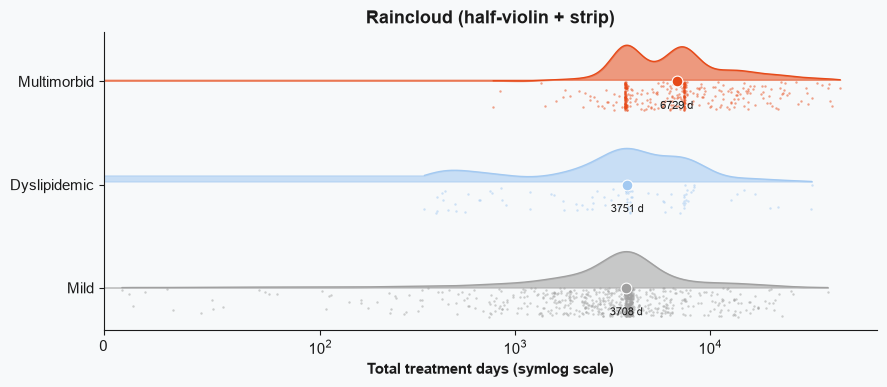

In [38]:
# 05_treatment_adherence.ipynb — Step 6: two alternative summary plots

fig, ax = plt.subplots(figsize=(9, 4))

# --- Plot B: Raincloud (half-violin + strip, offset) ---
# A raincloud plot separates the distribution shape (half-violin, top half only)
# from the individual points (strip, below), avoiding overlap between the two.
# It's increasingly common in clinical/neuroscience publications as it shows
# both density and raw data without one obscuring the other.
# Implementation: use violinplot clipped to one side via a post-hoc Path patch,
# approximated here with a KDE + fill_between approach for full control.

from scipy.stats import gaussian_kde

for i, label in enumerate(cluster_order):
    subset = df_pharma.loc[
        df_pharma["cluster_label"] == label, "treatment_days_total"
    ].values
    color = cluster_colors[label]

    # KDE on log-transformed data for smoothness, then exponentiate back
    log_vals = np.log1p(subset)
    kde = gaussian_kde(log_vals, bw_method=0.25)
    x_log = np.linspace(log_vals.min(), log_vals.max(), 300)
    y_kde = kde(x_log)
    x_raw = np.expm1(x_log)

    # Normalize KDE height to 0.35 (half the inter-cluster spacing of 1.0)
    y_kde_norm = y_kde / y_kde.max() * 0.35

    # Half-violin: fill above the cluster baseline
    ax.fill_betweenx(
        i + y_kde_norm, x_raw,
        alpha=0.55, color=color
    )
    ax.plot(x_raw, i + y_kde_norm, color=color, linewidth=1)

    # Strip below the baseline
    rng = np.random.default_rng(42)
    jitter = rng.uniform(-0.28, 0.0, size=len(subset))
    ax.scatter(
        subset, i + jitter,
        color=color, alpha=0.5, s=3, linewidths=0, zorder=2
    )

    # Median marker
    median_val = np.median(subset)
    ax.scatter(
        median_val, i, color=color, s=60,
        zorder=4, edgecolors="white", linewidths=0.8
    )
    ax.annotate(
        f"{median_val:.0f} d", xy=(median_val, i),
        xytext=(0, -14), textcoords="offset points",
        fontsize=8, color=COLOR_DARK, ha="center", va="top"
    )

ax.set_xscale("symlog", linthresh=100)
ax.set_xlim(left=0)
ax.set_xlabel("Total treatment days (symlog scale)")
ax.set_ylabel("")
ax.set_yticks(range(len(cluster_order)))
ax.set_yticklabels(["Mild", "Dyslipidemic", "Multimorbid"])
ax.set_title("Raincloud (half-violin + strip)")
sns.despine(ax=ax)

plt.tight_layout()
plt.show()